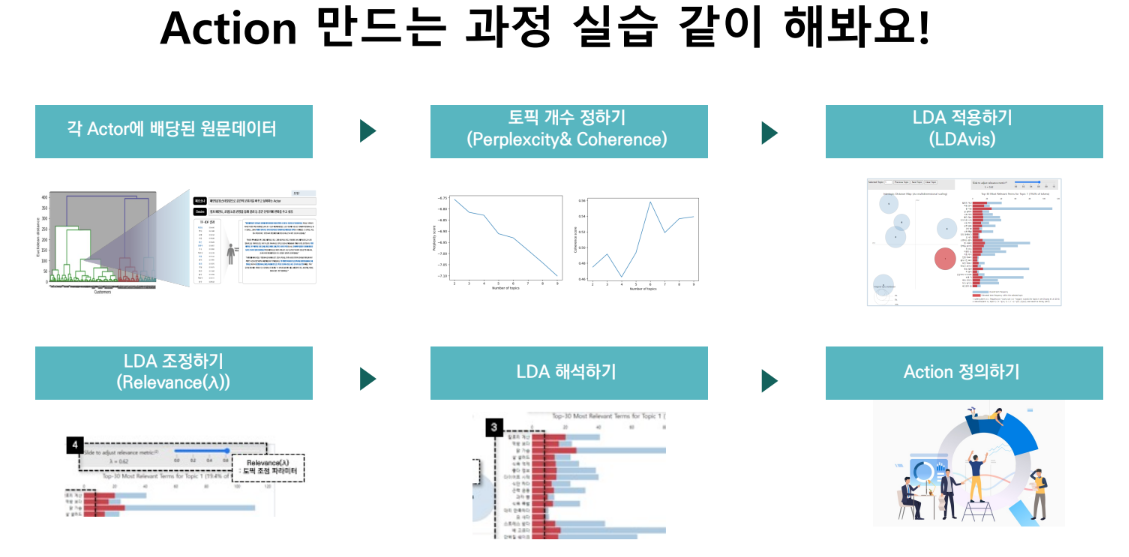

### 0.군집데이터 불러오기

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_pickle("/content/drive/MyDrive/Colab Notebooks/26.02 LG전자DX스쿨/2. DCX 분석/data/cluster_df.pkl")

In [ ]:
df.head()

,time,review,review_clean,tagged_review,vector,cluster
0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,"[가계부, 지출, 생활비, 정산, 만, 원, 가계부, 인, 가구, 자취, 생활비, ...","[0.010171594, 0.037157003, -0.01063898, -0.047...",2
1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,"[신혼부부, 가계부, 신혼부부, 가계부, 화목, 화목, 신혼부부, 가계부, 입당, ...","[-0.034408063, -0.014115097, 0.0224063, -0.009...",2
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,"[예금, 진실, 문득, 투자, 경제, 흐름, 알다, 예금, 안정, 이자, 바라보다,...","[0.012910142, 0.0046147835, -0.012872233, -0.0...",2
3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,"[카카오, 뱅크, 청년, 전세, 자금, 대출, 연장, 금리, 변동, 카카오, 뱅크,...","[0.06184401, 0.07119349, -0.07150183, -0.02208...",2
4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,"[탕, 다시다, 가다, 삼성, 병원, 가지, 베이컨, 그라탕, 해, 먹기, 미치다,...","[-0.08252463, -0.004896902, -0.03255208, -0.03...",0


### 1.LDA 이해하기

#### LDA(Latent Dirichlet Allocation)
- 토픽 모델링 : 문서의 집합으로부터 어떤 토픽이 존재하는지를 알아내기 위한 알고리즘
- LDA : 토픽 모델링의 대표적인 알고리즘
  - 주어진 문서에 대하여 각 문서에 어떤 주제들이 존재하는지에 대한 확률모형
  - 토픽별 단어의 분포, 문서별 토픽의 분포를 모두 추정
  - 실제 수십만개 이상의 문서가 있는 경우에는 직접 토픽을 찾아내는 것이 어렵기 때문에 LDA의 도움이 필요

- LDA는 특정 토픽에 특정 단어가 나타날 확률을 추정
  - 노란색 토픽에는 gene이라는 단어가 등장할 확률이 0.04, dna는 0.02, genetic은 0.01이므로 노란색 토픽은 대략 유전자 관련 주제로 추정
    - 주어진 문서를 보면 파란색, 분홍색 토픽에 해당하는 단어보다는 노란색 토픽에 해당하는 단어들이 많으므로 문서의 메인 주제는 유전자 관련일 가능성이 큼

<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx07.png" width=50%>   
</center>

#### LDA 프로세스
[참고: WikiDocs - LDA 프로세스](https://wikidocs.net/30708)

1. 토픽 개수 k 설정
- 사용자가 LDA에 미리 토픽 개수(k)를 지정
2. 초기 토픽 할당
- 모든 문서의 각 단어에 대해, k개의 토픽 중 랜덤으로 하나를 할당
- 결과 : 각 문서는 여러 토픽에 속하며, 각 토픽은 단어 분포를 갖게 됨
3. 토픽 재할당 반복
- 목표 : 잘못 할당된 단어를 올바른 토픽으로 재분류하여, 문서와 토픽의 분포 개선
- 가정 : 문서 d의 단어 w는 현재 잘못된 토픽에 할당되어 있고, 나머지 단어들은 올바르게 할당되어 있다고 봄
- 재할당 기준 :
  - 문서 내 기준 : 문서 d내에서 토픽 t에 속한 단어들의 비율
  - 전체 문서 기준 : 전체 문서에서 토픽 t가 단어 w를 얼마나 잘 설명하는지(w의 분포)
  - 이 두 기준을 종합하여 각 단어 w의 토픽 할당을 반복적으로 재조정

### 2.LDA를 위한 데이터 전처리
- 단어토큰을 이용해서 단어사전 생성
- 각 문서별 단어의 등장 빈도 측정(BOW)

In [ ]:
# 군집 수 확인
print("0번 군집 : ", df[df['cluster']==0].shape)
print("1번 군집 : ", df[df['cluster']==1].shape)
print("2번 군집 : ", df[df['cluster']==2].shape)

0번 군집 :  (450, 6)
1번 군집 :  (200, 6)
2번 군집 :  (369, 6)


In [ ]:
# actor가 도출된 군집을 기준으로 데이터 필터링
df_cluster_0 = df[df['cluster']==0]
df_cluster_0.head()

,time,review,review_clean,tagged_review,vector,cluster
4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,"[탕, 다시다, 가다, 삼성, 병원, 가지, 베이컨, 그라탕, 해, 먹기, 미치다,...","[-0.08252463, -0.004896902, -0.03255208, -0.03...",0
5,2022. 9. 24. 15:01,직장인은 잠을 줄여야 한다 갓생살기 갓생살기 미라클 모닝시에 일어나 공복에 애플...,직장인은 잠을 줄여야 한다 갓생살기 갓생살기 미라클 모닝시에 일어나 공복에 애플...,"[직장인, 잠, 줄이다, 생, 살기, 생, 살기, 미라클, 모닝, 시, 일어나다, ...","[-0.044130754, -0.018465854, 0.054839566, -0.0...",0
7,2022. 6. 8. 20:45,시작 게을러져서 아니면 글 못씀 주에 한 번 써야되는거같은데 상품은 ...,시작 게을러져서 아니면 글 못씀 주에 한 번 써야되는거같은데 상품은 ...,"[시작, 게으르다, 아니다, 글, 쓰다, 주, 번, 써다, 상품, 받다, 다시, 번...","[-0.066892564, 0.026184112, -0.0751055, -0.058...",0
8,2022. 7. 24. 12:02,차 이번 주에 무엇을 했나요 주차 했다 갔다 샀다 먹었다 봤다 ...,차 이번 주에 무엇을 했나요 주차 했다 갔다 샀다 먹었다 봤다 ...,"[차, 주, 주차, 가다, 사다, 먹다, 보다, 구별, 특별하다, 날, 감정, 치료...","[-0.0047695916, 0.057049688, -0.11943286, -0.0...",0
10,2022. 9. 13. 14:17,용 년 월 첫째주 이번주의 순간들 회사 칭구 따라서카드설계사 통해서 프리미엄 카드...,용 년 월 첫째주 이번주의 순간들 회사 칭구 따라서카드설계사 통해서 프리미엄 카드...,"[용, 주, 주의, 순간, 회사, 칭구, 카드, 설다, 통해, 프리미엄, 카드, 바...","[0.0013324526, 0.047646172, -0.04932052, -0.06...",0


#### 단어사전 생성 : 문서별 단어마다 고유한 ID 부여

In [ ]:
!pip install new_value_analysis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.3 MB/s eta 0:00:00


In [ ]:
from gensim.corpora import Dictionary # 단어사전 구축용 도구

In [ ]:
all_document = list(df_cluster_0['tagged_review'])
all_document

[['탕',
  '다시다',
  '가다',
  '삼성',
  '병원',
  '가지',
  '베이컨',
  '그라탕',
  '해',
  '먹기',
  '미치다',
  '폭우',
  '전쟁',
  '급',
  '양양',
  '떠나다',
  '아버지',
  '진료',
  '때문',
  '병원',
  '들리다',
  '시반',
  '도착',
  '진료',
  '보고',
  '기다리다',
  '처치',
  '받다',
  '벌써',
  '점심시간',
  '근처',
  '김',
  '선생',
  '크다',
  '호',
  '김밥',
  '먹다',
  '땡기다',
  '준',
  '다해',
  '호다닥',
  '먹다',
  '들어가다',
  '제발',
  '나다',
  '좋다',
  '후',
  '웃기다',
  '카톡',
  '캡쳐',
  '뇌',
  '수준',
  '넘다',
  '웃기다',
  '카톡',
  '캡쳐',
  '이틀',
  '번',
  '맞추다',
  '신기하다',
  '웃기다',
  '캡쳐',
  '놈',
  '쓰다',
  '아버지',
  '진주',
  '보내다',
  '드리다',
  '오다',
  '장보고',
  '만들다',
  '가지',
  '베이컨',
  '그라탕',
  '윗',
  '우영',
  '우근',
  '가지',
  '맛',
  '머리',
  '아프다',
  '맛',
  '멀미',
  '맛',
  '나다',
  '소스',
  '덕',
  '해치',
  '움',
  '후식',
  '야무지다',
  '챙기다',
  '먹음',
  '복숭아',
  '윗',
  '우영',
  '달달',
  '복숭아',
  '기분',
  '좋다',
  '폭우',
  '도랏맨',
  '고요',
  '진짜',
  '핵',
  '혐',
  '천둥',
  '번개',
  '내',
  '살다',
  '제일',
  '컷던',
  '순간',
  '창문',
  '흔들리다',
  '느낌',
  '막',
  '커튼',
  '아니다',
  '잠',
  '절대',
  '못자다',
  '짤',


In [ ]:
# 단어사전 구축
word_dict = Dictionary(all_document)

In [ ]:
# 단어사전 확인
print(word_dict) # 17618개 단어토큰 확인
print(word_dict.token2id)

Dictionary<17618 unique tokens: ['가다', '가운데', '가지', '개', '개다']...>
{'가다': 0, '가운데': 1, '가지': 2, '개': 3, '개다': 4, '거냠': 5, '계속': 6, '고요': 7, '곸': 8, '그라탕': 9, '근처': 10, '금액': 11, '급': 12, '기다': 13, '기다리다': 14, '기분': 15, '김': 16, '김밥': 17, '끄다': 18, '나다': 19, '나오다': 20, '나일': 21, '나혼산': 22, '낙성대': 23, '난방': 24, '날': 25, '남기다': 26, '남다': 27, '내': 28, '내일': 29, '넘다': 30, '넣다': 31, '노맛': 32, '놈': 33, '뇌': 34, '느낌': 35, '다시다': 36, '다해': 37, '단말': 38, '달달': 39, '대사': 40, '덕': 41, '뎈': 42, '도랏맨': 43, '도착': 44, '동동': 45, '돜': 46, '돼지': 47, '드리다': 48, '들다': 49, '들리다': 50, '들어가다': 51, '듯': 52, '때문': 53, '땡기다': 54, '떠나다': 55, '떠오르다': 56, '라따뚜이': 57, '마르다': 58, '막': 59, '만들다': 60, '만원': 61, '많다': 62, '말': 63, '말이냠': 64, '맑다': 65, '맑은': 66, '맛': 67, '맛있다': 68, '맞추다': 69, '매콤': 70, '머리': 71, '먹기': 72, '먹다': 73, '먹음': 74, '멀다': 75, '멀미': 76, '모든': 77, '못자다': 78, '무': 79, '무도': 80, '무한도전': 81, '뭔가': 82, '미치다': 83, '받다': 84, '밥': 85, '버리다': 86, '번': 87, '번개': 88, '벌써': 89, '베이컨': 90, '병원': 91, '보고': 92,

#### 문서별로 단어등장 빈도 측정(BOW)

In [ ]:
# 샘플문장 변경
print(all_document[0])
print(word_dict.doc2bow(all_document[0]))

['탕', '다시다', '가다', '삼성', '병원', '가지', '베이컨', '그라탕', '해', '먹기', '미치다', '폭우', '전쟁', '급', '양양', '떠나다', '아버지', '진료', '때문', '병원', '들리다', '시반', '도착', '진료', '보고', '기다리다', '처치', '받다', '벌써', '점심시간', '근처', '김', '선생', '크다', '호', '김밥', '먹다', '땡기다', '준', '다해', '호다닥', '먹다', '들어가다', '제발', '나다', '좋다', '후', '웃기다', '카톡', '캡쳐', '뇌', '수준', '넘다', '웃기다', '카톡', '캡쳐', '이틀', '번', '맞추다', '신기하다', '웃기다', '캡쳐', '놈', '쓰다', '아버지', '진주', '보내다', '드리다', '오다', '장보고', '만들다', '가지', '베이컨', '그라탕', '윗', '우영', '우근', '가지', '맛', '머리', '아프다', '맛', '멀미', '맛', '나다', '소스', '덕', '해치', '움', '후식', '야무지다', '챙기다', '먹음', '복숭아', '윗', '우영', '달달', '복숭아', '기분', '좋다', '폭우', '도랏맨', '고요', '진짜', '핵', '혐', '천둥', '번개', '내', '살다', '제일', '컷던', '순간', '창문', '흔들리다', '느낌', '막', '커튼', '아니다', '잠', '절대', '못자다', '짤', '때문', '통', '거냠', '스폭', '우도', '좀비', '직장인', '막', '수', '없다', '없다', '없다', '무', '없다', '없다', '무한도전', '비때매', '인간', '진주', '개다', '말이냠', '위치', '돜', '와중', '가운데', '멀다', '중립', '오다', '화장실', '셀카', '존', '비다', '날', '마르다', '재질', '셔츠', '회사', '넘다', '춥다', '기다', '입',

In [ ]:
# 전체문서에 BOW실행
corpus = [ word_dict.doc2bow(doc)  for doc in all_document  ]

In [ ]:
# 샘플확인
print(corpus[350])

[(0, 1), (10, 1), (14, 2), (25, 1), (28, 4), (30, 4), (49, 5), (52, 3), (61, 1), (63, 1), (68, 1), (73, 1), (84, 2), (86, 3), (87, 2), (92, 1), (93, 1), (94, 3), (104, 1), (121, 1), (123, 3), (124, 2), (136, 1), (138, 1), (164, 1), (166, 1), (182, 2), (195, 1), (200, 1), (214, 2), (215, 3), (221, 1), (231, 1), (240, 1), (254, 1), (259, 1), (261, 1), (263, 1), (275, 1), (290, 2), (302, 1), (305, 1), (316, 1), (324, 1), (329, 3), (334, 2), (338, 3), (339, 1), (343, 3), (353, 1), (358, 2), (384, 2), (385, 2), (389, 3), (390, 3), (398, 4), (408, 2), (437, 1), (447, 1), (474, 2), (478, 1), (490, 2), (493, 1), (494, 1), (508, 5), (509, 1), (523, 1), (544, 1), (549, 1), (552, 1), (557, 1), (566, 1), (642, 1), (645, 1), (684, 1), (686, 1), (706, 1), (715, 7), (732, 1), (733, 1), (742, 1), (752, 1), (754, 2), (792, 1), (795, 1), (804, 2), (805, 1), (818, 3), (856, 1), (887, 1), (906, 1), (975, 1), (986, 2), (1001, 1), (1031, 1), (1050, 1), (1070, 1), (1129, 1), (1200, 1), (1257, 1), (1270, 1), 

### 3.LDA 모델 만들기

#### 3.1 LDA 테스트

In [ ]:
import gensim

In [ ]:
topic_num = 3 # 생성할 토픽 수 설정(임의로 설정)

In [ ]:
# 모델생성
ldamodel = gensim.models.ldamodel.LdaModel(
    corpus, # 각 문서를 단어 빈도수(BOW)로 표현한 데이터
    id2word = word_dict, # 단어사전 연결
    num_topics = topic_num, # 설정할 토픽 수
    passes = 10, # 전체 코퍼스를 대상으로 몇번이나 반복할지 설정
    iterations = 20, # 각 문서별로 재할당하는 횟수 설정
    # 너무 과대적합이 되지않도록 적당한 iterations를 설정하는게 중요
    random_state = 2026 # 난수 시드값 고정 : 결과재현성 고정
)

In [ ]:
# 각 토픽별로 중요한 상위 단어 확인
ldamodel.print_topics(num_words = 10)

[(0,
  '0.008*"보다" + 0.008*"내" + 0.007*"생각" + 0.007*"먹다" + 0.006*"없다" + 0.006*"가다" + 0.006*"수" + 0.006*"좋다" + 0.006*"않다" + 0.006*"들다"'),
 (1,
  '0.015*"먹다" + 0.008*"보다" + 0.007*"가다" + 0.007*"좋다" + 0.006*"진짜" + 0.006*"오다" + 0.006*"없다" + 0.004*"내" + 0.004*"날" + 0.004*"맛있다"'),
 (2,
  '0.011*"보다" + 0.011*"먹다" + 0.009*"가다" + 0.007*"없다" + 0.007*"내" + 0.006*"오다" + 0.006*"거" + 0.005*"좋다" + 0.005*"들다" + 0.005*"아니다"')]

In [ ]:
# 특정문서의 할당된 토픽 확인하기
corpus_topics = ldamodel.get_document_topics(corpus)
print(corpus_topics[135])

[(0, np.float32(0.62843)), (2, np.float32(0.37042302))]


#### 3.2 토픽개수 선정

- LDA 모델의 성능을 평가하고 적절한 토픽 개수를 선정하기 위해 Perplexity(혼란도)와 Coherence(일관성) 지표를 활용

> 1. Perplexity(혼란도)  
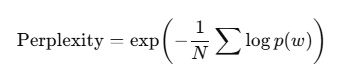
> - LDA 모델이 새로운 데이터에서 단어 또는 토픽의 분포를 얼마나 잘 예측하는지를 나타내는 평가지표
> 해석 :
>   - 낮은 값 : 모델이 데이터의 패턴을 잘 학습하여 예측력이 뛰어남
>   - 높은 값 : 모델의 예측력이 떨어짐
> - 주의사항 :
>   - 낮은 perplexity 값이 반드시 사람이 해석하기 좋은, 직관적인 토픽 구성을 보장하지는 않음
>   - 토픽 재할당 반복 횟수가 증가함에 따라 perplexity는 일반적으로 감소하지만, 특정 시점 이후에는 더 이상 감소하지 않거나 오히려 증가하는 현상이 발생할 수 있음(과적합)

> 2. Coherence(일관성)
> - 각 토픽 내에서 등장하는 단어들이 의미적으로 얼마나 연관되어 있는지를 측정하는 지표
> - 이는 사람이 해석하기에 얼마나 적합한 토픽인지 평가하기 위해서 제안됨(2010)
> - 해석 :
>   - 높은 값 : 토픽 내 단어들이 서로 의미적으로 연관이 깊어, 사람이 이해하기 쉬운 토픽임을 나타냄
>   - 낮은 값 : 토픽 내 단어들이 무작위로 나열되었거나, 관련성이 낮아 해석이 어렵다는 의미
> - 주의 사항 :
>   - 높은 Coherence 값이 반드시 모델이 최적의 일반화 성능을 가졌다는 의미는 아님
>   - 경우에 따라 너무 특정한 주제에 국한된 토픽이 만들어져, 과도하게 세부적이거나 제한된 정보를 제공할 위험이 있음
>   - 과적합의 가능성이 있으므로, Coherence 만으로 평가하기보다는 다른 지표(perplexity)와 함께 고려하는 것이 좋음

In [ ]:
# perplexity 계산해보기
print("perplexity 점수 : ", ldamodel.log_perplexity(corpus)) # 마이너스 처리가 없는 함수

perplexity 점수 :  -8.273928710917168


In [ ]:
# 일반적인 perplexity 값으로 확인
import numpy as np

print("일반적인 perplexity 점수 : ", np.exp(-ldamodel.log_perplexity(corpus)) )

일반적인 perplexity 점수 :  3920.2852500687177


In [ ]:
# coherence 사용해보기
from gensim.models import CoherenceModel

In [ ]:
coherence_model = CoherenceModel(
    model = ldamodel, # 평가할 모델
    texts = all_document, # 토픽간 단어 관련성을 측정
    dictionary = word_dict, # 단어사전
    topn = 10 # 측정대상을 토픽별 상위 10개 단어로 제한
)

In [ ]:
print("coherence 점수 : ", coherence_model.get_coherence())

coherence 점수 :  0.33493385075502974


#### 3.3 토픽 수 별로 perplexity와 coherence 확인하기

In [ ]:
from new_value_analysis.action_finder import lda_perplexity_coherence_plot

  0%|          | 0/8 [00:00<?, ?it/s]

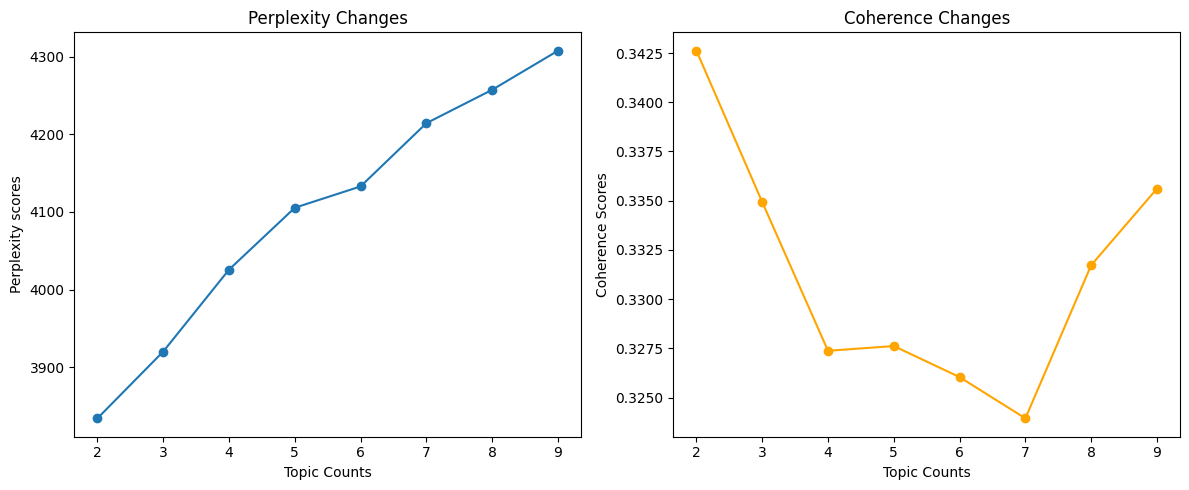

In [ ]:
lda_perplexity_coherence_plot(
    corpus = corpus, # BOW 형태되있는 말뭉치데이터
    word_dict = word_dict, # 단어사전
    passes = 10, # 전체 말뭉치 반복 횟수
    iterations = 20, # 문서별 재할당 계산 횟수
    topic_range = range(2,10), # 2~9까지 토픽수 설정
    random_state = 2026, # 결과 재현성 유지
    all_documents = all_document, # 문서 리스트
    fixed_topn = 10 # 토픽별 상위 단어 수 설정
)

- 분석 진행시 perplexity와 coherence를 고려하여 해석
- perplexity은 낮을수록 좋고, coherence는 높을수록 좋다
- 여러 토픽 수 후보를 선정하고 하나씩 시각화하여 해석해보자

#### 3.4 선정한 토픽 개수로 학습 후 action 넘버 매칭

In [ ]:
topic_num = 3

In [ ]:
# 모델생성
ldamodel = gensim.models.ldamodel.LdaModel(
    corpus, # 각 문서를 단어 빈도수(BOW)로 표현한 데이터
    id2word = word_dict, # 단어사전 연결
    num_topics = topic_num, # 설정할 토픽 수
    passes = 10, # 전체 코퍼스를 대상으로 몇번이나 반복할지 설정
    iterations = 20, # 각 문서별로 재할당하는 횟수 설정
    # 너무 과대적합이 되지않도록 적당한 iterations를 설정하는게 중요
    random_state = 2026 # 난수 시드값 고정 : 결과재현성 고정
)

In [ ]:
from new_value_analysis.action_finder import assign_action_number

In [ ]:
action_number_assignment = assign_action_number(
    ldamodel, # 학습한 LDA모델 넣기
    corpus = corpus
)

In [ ]:
# 토픽별 단어확인
ldamodel.print_topics(num_words=10)

In [ ]:
action_number_assignment

In [ ]:
# 액션넘버를 새로운 컬럼으로 지정하고 파일로 저장
df_cluster_0['action_cluster'] = action_number_assignment
df_cluster_0.to_pickle("/content/drive/MyDrive/Colab Notebooks/26.02 LG전자DX스쿨/2. DCX 분석/data/actor_0_action.pkl")

In [ ]:
df_cluster_0.head()

,time,review,review_clean,tagged_review,vector,cluster,action_cluster
4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,"[탕, 다시다, 가다, 삼성, 병원, 가지, 베이컨, 그라탕, 해, 먹기, 미치다,...","[-0.08252463, -0.004896902, -0.03255208, -0.03...",0,1
5,2022. 9. 24. 15:01,직장인은 잠을 줄여야 한다 갓생살기 갓생살기 미라클 모닝시에 일어나 공복에 애플...,직장인은 잠을 줄여야 한다 갓생살기 갓생살기 미라클 모닝시에 일어나 공복에 애플...,"[직장인, 잠, 줄이다, 생, 살기, 생, 살기, 미라클, 모닝, 시, 일어나다, ...","[-0.044130754, -0.018465854, 0.054839566, -0.0...",0,1
7,2022. 6. 8. 20:45,시작 게을러져서 아니면 글 못씀 주에 한 번 써야되는거같은데 상품은 ...,시작 게을러져서 아니면 글 못씀 주에 한 번 써야되는거같은데 상품은 ...,"[시작, 게으르다, 아니다, 글, 쓰다, 주, 번, 써다, 상품, 받다, 다시, 번...","[-0.066892564, 0.026184112, -0.0751055, -0.058...",0,2
8,2022. 7. 24. 12:02,차 이번 주에 무엇을 했나요 주차 했다 갔다 샀다 먹었다 봤다 ...,차 이번 주에 무엇을 했나요 주차 했다 갔다 샀다 먹었다 봤다 ...,"[차, 주, 주차, 가다, 사다, 먹다, 보다, 구별, 특별하다, 날, 감정, 치료...","[-0.0047695916, 0.057049688, -0.11943286, -0.0...",0,0
10,2022. 9. 13. 14:17,용 년 월 첫째주 이번주의 순간들 회사 칭구 따라서카드설계사 통해서 프리미엄 카드...,용 년 월 첫째주 이번주의 순간들 회사 칭구 따라서카드설계사 통해서 프리미엄 카드...,"[용, 주, 주의, 순간, 회사, 칭구, 카드, 설다, 통해, 프리미엄, 카드, 바...","[0.0013324526, 0.047646172, -0.04932052, -0.06...",0,2


### 4.LDA 토픽모델링 시각화

#### 4.1 액션 비율 확인하기

In [ ]:
df_cluster_0['action_cluster'].value_counts()

,count
action_cluster,
2,175
0,165
1,110


#### 4.2 pyLDAvis 활용하기
1. 왼쪽 : 각 토픽들의 거리와 크기를 비교하면서 분석
  - 토픽별 거리가 넓다면 사용되는 단어 그룹이 많이 차이난다
  - 토픽별 거리가 가깝다면 사용되는 단어 그룹이 비슷하다  

2. 오른쪽 : 전체 말뭉치에서 단어의 등장빈도와 특정토픽에서 특별하게 등장하는 단어의 중요성을 확인
  - 람다 (0~1 조절) : 전체 말뭉치의 등장빈도와 특정토픽 중요도의 가중치를 조절하는 파라미터
  - 람다가 1에 가까울수록 전체 말뭉치의 등장빈도 비중을 높인다
  - 람다가 0에 가까울수록 특정토픽에 등장하는 단어의 비중을 높인다
  - 보통 논문에서는 0.5~0.6을 추천 (전체 단어등장 비율과 특정토픽의 중요성을 반정도 섞는게 이상적이라고 보기때문)

In [ ]:
!pip install pyldavis

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis # pyLDAvis와 gensim LDA모델을 연결하는 패키지

In [ ]:
# 시각화하기 위한 데이터 형태로 변경
prepared_data = gensimvis.prepare(
    ldamodel, # 학습한 LDA모델
    corpus, # 각 문서를 BOW로 변경한 데이터
    word_dict # 단어사전
)

In [ ]:
pyLDAvis.display(prepared_data)

In [ ]:
# HTML파일로 저장하기
pyLDAvis.save_html(
  prepared_data, # 준비한 데이터 넣기
  "./ldavis_actor0_action.html" # 저장할 파일경로 및 파일명
)

### 5.LDA 분석을 위한 작업
- LDA모델의 토픽 인덱스 번호와 pyLDAvis의 토픽 인덱스 번호가 불일치(별도의 모델)
- 해석의 편의성을 위해 pyLDAvis 기준으로 action 번호 수정

In [ ]:
# LDA모델의 토픽번호 확인
ldamodel.print_topics(num_words=10)

[(0,
  '0.008*"보다" + 0.008*"내" + 0.007*"생각" + 0.007*"먹다" + 0.006*"없다" + 0.006*"가다" + 0.006*"수" + 0.006*"좋다" + 0.006*"않다" + 0.006*"들다"'),
 (1,
  '0.015*"먹다" + 0.008*"보다" + 0.007*"가다" + 0.007*"좋다" + 0.006*"진짜" + 0.006*"오다" + 0.006*"없다" + 0.004*"내" + 0.004*"날" + 0.004*"맛있다"'),
 (2,
  '0.011*"보다" + 0.011*"먹다" + 0.009*"가다" + 0.007*"없다" + 0.007*"내" + 0.006*"오다" + 0.006*"거" + 0.005*"좋다" + 0.005*"들다" + 0.005*"아니다"')]

In [ ]:
#  LDA -> pyLDAvis
#  0 -> 2
#  1 -> 3
#  2 -> 1

new_action_topic = [] # 새로운 토픽번호로 매핑된 리스트
for i in df_cluster_0['action_cluster'] : # 기존 action번호를 반복처리
  if i == 0 :
    new_action_topic.append(2)
  elif i == 1 :
    new_action_topic.append(3)
  elif i == 2 :
    new_action_topic.append(1)

In [ ]:
# pyLDAvis 기준으로 업데이트
df_cluster_0['action_cluster'] = new_action_topic
# 파일 저장
df_cluster_0.to_pickle("/content/drive/MyDrive/Colab Notebooks/26.02 LG전자DX스쿨/2. DCX 분석/data/actor_0_action.pkl")

In [ ]:
# 필터링
topic3 = df_cluster_0.loc[df_cluster_0['action_cluster'] == 3,'review']
topic3.loc[topic3.str.contains("애견|챗봇")]

,review
135,괜찮아지겠지 갖고왔어요 힘든 월요일은 지오디 노래로 시작 또한 매머드 아아 주문...
356,신한은행이시여 제발 저한테 이러지 마소서 챗봇 색이 가만안도 이번주 진짜 ...
768,월 주 급하게 생각나서 쓰는 인데 사진을 마니 못찍어서중간중간 없다 아무튼 ...


### 6.인스타그램데이터 실습
- 약 1700개 정도 데이터 (aihub 공개데이터)
- 데이터 클렌징이 실시된 데이터
  1. 화자번호 제거
  2. 영어,숫자,한글을 제외한 나머지 데이터 제거
  3. 불용어/어간추출/정규화/품사필터링 처리

In [1]:
import pandas as pd

In [2]:
df = pd.read_pickle("/content/drive/MyDrive/Colab Notebooks/26.02 LG전자DX스쿨/2. DCX 분석/data/instagram_tagged_reviews.pkl")

In [3]:
df.head()

,원본,clean text,review_clean,tagged_review
0,1 : 너는 여친이랑 기차 여행해 본 적 있어?\n2 : 나는 여자친구랑 기차 한 ...,너는 여친이랑 기차 여행해 본 적 있어? 나는 여자친구랑 기차 한 번도 안 타 봤어...,너는 여친이랑 기차 여행해 본 적 있어 나는 여자친구랑 기차 한 번도 안 타 봤어 ...,"[여친, 기차, 여행, 보다, 적, 여자친구, 기차, 번, 안, 타, 보다, 진짜,..."
1,1 : 너가 지금까지 했던 알바 중에 꿀알바는 뭐였어?\n2 : 나는 축구장 알바 ...,너가 지금까지 했던 알바 중에 꿀알바는 뭐였어? 나는 축구장 알바 한 게 꿀이였어 ...,너가 지금까지 했던 알바 중에 꿀알바는 뭐였어 나는 축구장 알바 한 게 꿀이였어 어...,"[지금, 알바, 중, 꿀, 알바, 뭐, 축구장, 알바, 게, 꾸다, 축구장, 알바,..."
2,1 : 너 때는 마음의 소리?\n1 : 그런 거 있었지?\n2 : 웅 나 때는 마음...,너 때는 마음의 소리? 그런 거 있었지? 웅 나 때는 마음의 소리 있었지 그렇지? ...,너 때는 마음의 소리 그런 거 있었지 웅 나 때는 마음의 소리 있었지 그렇지 너 거...,"[마음, 소리, 그렇다, 거, 웅, 마음, 소리, 그렇다, 거기, 다가, 건의, 사..."
3,1 : 너는 지금 배워 보고 싶은 거 있어?\n2 : 웅 난 왁싱 배워 보고 싶어\...,너는 지금 배워 보고 싶은 거 있어? 웅 난 왁싱 배워 보고 싶어 왁싱? 너 남자잖...,너는 지금 배워 보고 싶은 거 있어 웅 난 왁싱 배워 보고 싶어 왁싱 너 남자잖아 ...,"[지금, 배우다, 보고, 싶다, 거, 웅, 난, 왁싱, 배우다, 보고, 싶다, 왁싱..."
4,1 : 너네 집도 가족회의 같은 거 했었어?\n2 : 웅 우리 집 맨날 해\n2 :...,너네 집도 가족회의 같은 거 했었어? 웅 우리 집 맨날 해 가족회의 아 진짜? 너네...,너네 집도 가족회의 같은 거 했었어 웅 우리 집 맨날 해 가족회의 아 진짜 너네가 ...,"[집도, 가족, 회의, 거, 웅, 집, 해, 가족, 회의, 진짜, 화목, 이유, 알..."


In [ ]:
# 라이브러리 설치
!pip install new-value-analysis

#### 단어사전 생성 및 BOW 실시

In [5]:
from gensim.corpora import Dictionary

In [8]:
# 사용할 컬럼을 리스트로 변경
all_documents = list(df["tagged_review"])

In [10]:
# 단어사전 구축
word_dict = Dictionary(all_documents)

In [11]:
# 단어사전 확인
print(word_dict.token2id)

{'가다': 0, '가면': 1, '갈다': 2, '개': 3, '거': 4, '계획': 5, '교통사고': 6, '그거': 7, '그것': 8, '기차': 9, '끄다': 10, '나다': 11, '나쁘다': 12, '나서다': 13, '남다': 14, '남친': 15, '년도': 16, '달이': 17, '더': 18, '맞다': 19, '번': 20, '벌써': 21, '병가': 22, '보고': 23, '보다': 24, '부산': 25, '삐': 26, '상사': 27, '서울': 28, '신기하다': 29, '싶다': 30, '써다': 31, '아니다': 32, '안': 33, '알다': 34, '없다': 35, '여야': 36, '여자친구': 37, '여친': 38, '여행': 39, '역시': 40, '연차': 41, '예정': 42, '오다': 43, '외제차': 44, '웅': 45, '입원': 46, '재밌다': 47, '적': 48, '절대': 49, '정말': 50, '주다': 51, '줄': 52, '지금': 53, '진짜': 54, '치다': 55, '케이티엑스': 56, '키키': 57, '타': 58, '타고': 59, '후기': 60, '건가': 61, '게': 62, '계속': 63, '골프공': 64, '공': 65, '공설': 66, '구해': 67, '그렇다': 68, '꾸다': 69, '꿀': 70, '내과': 71, '누나': 72, '다니다': 73, '대박': 74, '도우미': 75, '돼다': 76, '뭐': 77, '병원': 78, '빼다': 79, '사람': 80, '서다': 81, '실': 82, '쌤': 83, '알바': 84, '역할': 85, '운동': 86, '운동장': 87, '은근': 88, '음': 89, '전혀': 90, '중': 91, '초음파': 92, '축구장': 93, '헐다': 94, '힘들다': 95, '가지': 96, '거기': 97, '건의': 98, '괴롭히다': 99, '그냥

In [12]:
# 전체문서에 BOW 실행
corpus = [ word_dict.doc2bow(doc)  for doc in all_documents ]

In [ ]:
corpus

#### 토픽 갯수 선정하기

In [14]:
from new_value_analysis.action_finder import lda_perplexity_coherence_plot

  0%|          | 0/8 [00:00<?, ?it/s]

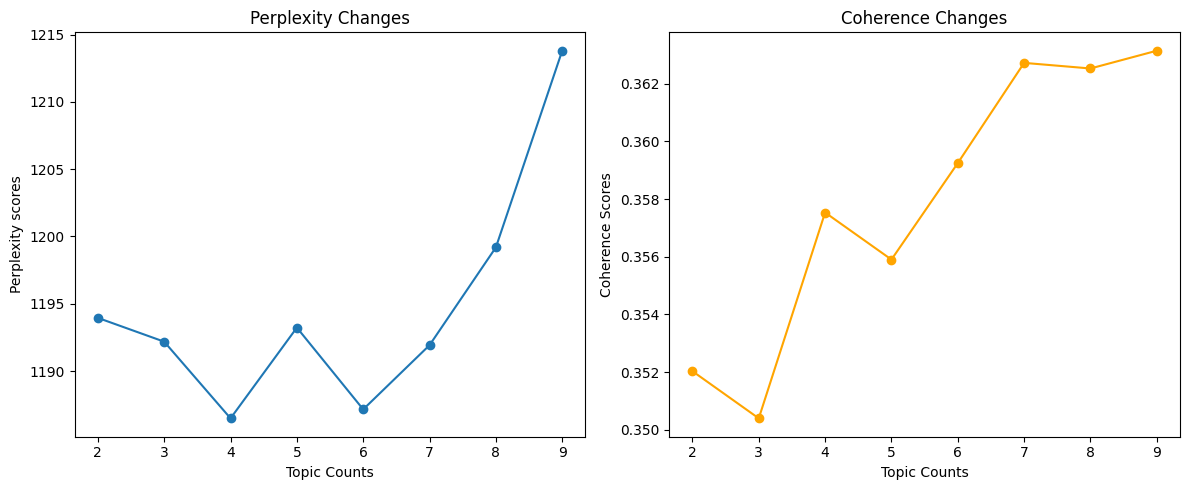

In [15]:
lda_perplexity_coherence_plot(
    corpus = corpus, # LDA학습에 사용할 데이터 (BOW 형식)
    word_dict = word_dict, # 단어 사전
    all_documents = all_documents, # 토큰화된 문서 리스트
    topic_range = range(2,10), # 평가할 토픽 개수 범위(2~9)
    passes = 10, # 전체 말뭉치를 몇번 반복해서 계산할건지 설정
    iterations = 20, # 하나의 문서 내부에서 몇번 반복할껀지 설정
    random_state = 2026, # 결과 재현성 유지
    fixed_topn = 10, # 토픽별 상위단어 갯수 설정(for coherence)
    figsize = (12,5) # 가로,세로 비율
)

- perplexity 값은 토픽 수 선정뿐 아니라 모델의 최적화 정도나 데이터셋 증가에 따른 LDA모델의 안정성 변화를 추척할때도 활용가능
- coherence가 토픽별 단어의 일관성을 말하기때문에 좀 더 중요, 위 데이터에서는 4개 or 6개 정도로 시작해보는게 좋겠다
- 데이터셋이 적은 경우 토픽이 많이 쪼개지면 보통 coherence 값이 올라가는 편

#### LDA 모델 학습 및 시각화

In [16]:
# 경고메시지 처리
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
# LDA모델 구현체가 들어있는 라이브러리 import
import gensim

In [17]:
topic_num = 4
# 모델생성
ldamodel = gensim.models.ldamodel.LdaModel(
    corpus, # BOW 형태의 데이터셋
    id2word = word_dict, # 단어사전
    num_topics = topic_num, # 토픽 수 설정
    passes = 10,
    iterations = 20,
    random_state = 2026
)

In [ ]:
# 라이브러리 설치
!pip install pyldavis

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis # pyLDAvis와 gensim 모델을 연결하는 패키지

In [ ]:
# 데이터 포맷 맞추기
prepared_data = gensimvis.prepare(
    ldamodel, # 학습한 LDA모델
    corpus, # 데이터셋
    word_dict # 단어사전
)

In [25]:
pyLDAvis.display(prepared_data)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
